In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# EDA

Q1. How many customers churned vs stayed?

In [ ]:

print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


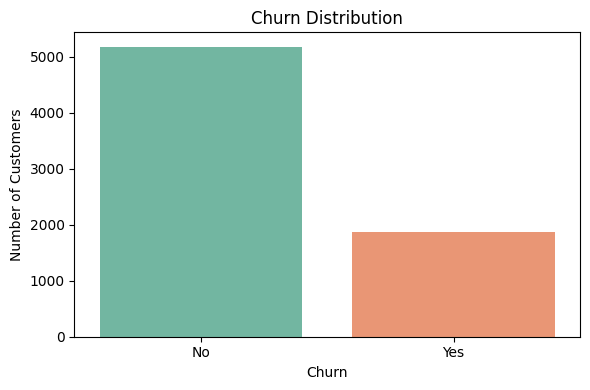

In [10]:
# Chart 1 — Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Q2. Do newer customers churn more than older ones?

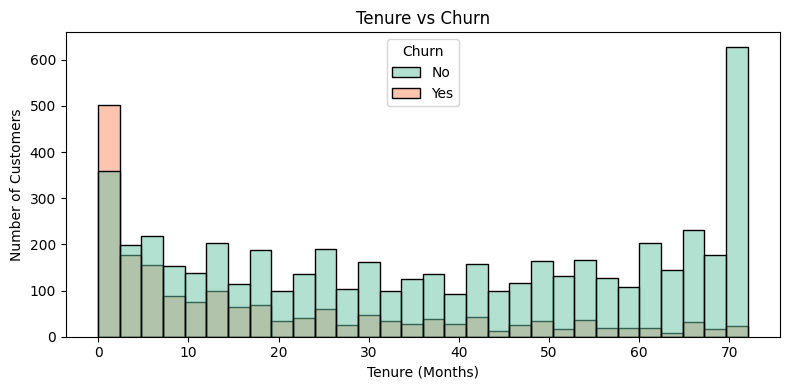

In [11]:
# Chart 2 — Tenure vs Churn
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

New customers (low tenure) - Churn MORE
Old customers (high tenure) - Churn LESS

Insight:- Target new customers (tenure < 6 months) with special offers immediately after joining.

Q3. Do customers who pay more tend to leave more?

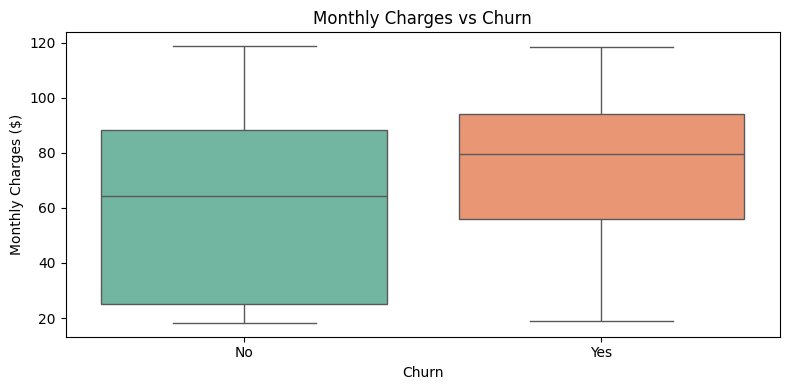

In [13]:
# Chart 3 — Monthly Charges vs Churn
plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2',hue='Churn')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

Insight:- Customers who left were paying around $80 per month, while those who stayed were paying about $60 per month. So, offering discounts or loyalty benefits to high-paying customers may help reduce churn.

Q4. Does the type of contract affect churn?

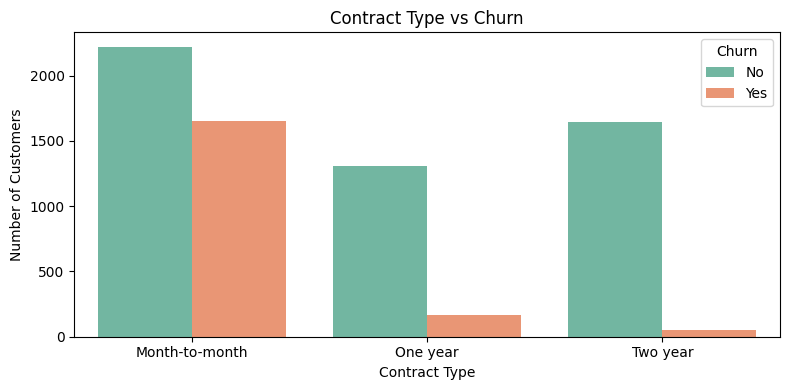

In [14]:
# Chart 4 — Contract Type vs Churn
plt.figure(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Push Month-to-month customers to yearly contracts.

Q5. Does Internet service affect churn ?

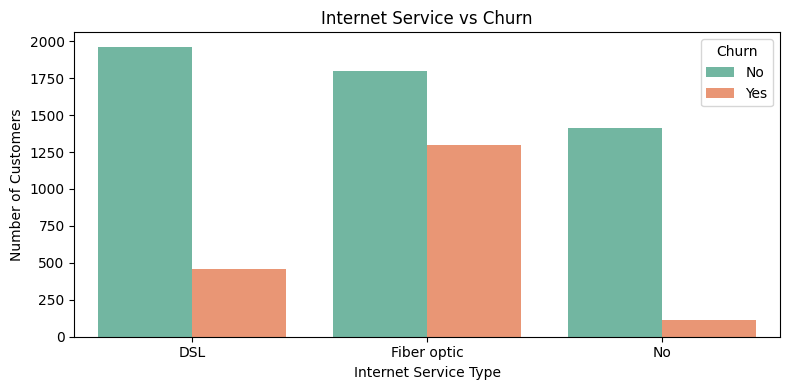

In [15]:
# Chart 5 — Internet Service vs Churn
plt.figure(figsize=(8, 4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Insight:- Customers using fiber optic internet have a very high churn rate, meaning they are more likely to leave.They need special attention — better service quality or loyalty rewards to justify the high cost.

Q6. Does Senior Citizen Churns ?

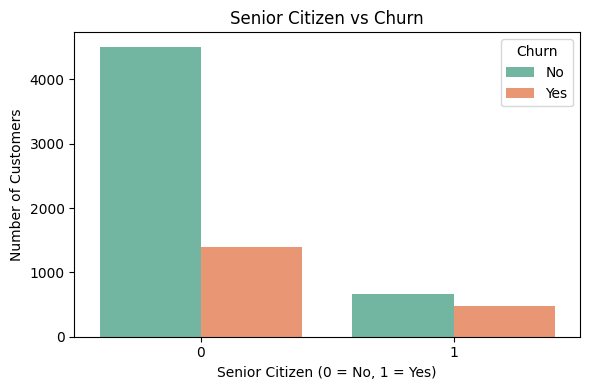

In [ ]:
# Chart 6-  Senior Citizen vs Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set2')
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [17]:
# Exact churn rate by senior citizen
print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100)

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64


Insight - Senior citizens churn at 41.6% — nearly double the average. They need dedicated support, simpler plans, and special pricing

# Data Cleaning

In [20]:
# Check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [21]:
# Check data types of all columns
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
#Drop Customer ID
df = df.drop('customerID', axis=1)

print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
#Fix TotalCharges data type
print(df['TotalCharges'].unique()[:10])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']


In [28]:
# Convert TotalCharges to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [30]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [31]:
# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [32]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [33]:
# Convert Churn Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm
print(df['Churn'].value_counts())
print(df['Churn'].dtype)

Churn
0    5174
1    1869
Name: count, dtype: int64
int64


In [34]:
# Check remaining text columns
text_columns = df.select_dtypes(include='object').columns.tolist()
print("Text columns remaining:", len(text_columns))
print(text_columns)

Text columns remaining: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Check unique values 
for col in text_columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [36]:
# Binary encoding for 2-value columns
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_columns:
    df[col] = df[col].map({df[col].unique()[0]: 0, df[col].unique()[1]: 1})

print(df[binary_columns].head())

   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        0           0             0                 0
1       1        1           0             1                 1
2       1        1           0             1                 0
3       1        1           0             0                 1
4       0        1           0             1                 0


In [37]:
# One hot encoding for 3+ value columns
ohe_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=ohe_columns, drop_first=True)

# Confirm new shape
print("New shape:", df.shape)

New shape: (7043, 31)


In [38]:
# Final check
print("Shape:", df.shape)
print("\nAny missing values?")
print(df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 31)

Any missing values?
0

Data types:
bool       21
int64       8
float64     2
Name: count, dtype: int64

First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,1,0,0,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,1,0,34,1,1,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,1,0,2,1,0,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,1,0,45,0,1,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,1,0,2,1,0,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [40]:
# Save cleaned data
df.to_csv('data/cleaned_churn.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
